<a href="https://colab.research.google.com/github/seongwoojang1123/TMJ-Effusion-and-Pain/blob/main/4_feature_significance_analysis_Effusion.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import re
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.api as sm
import matplotlib.patheffects as pe
import matplotlib.patches as mpatches

from matplotlib.patches import PathPatch, Rectangle
from matplotlib.path import Path
from matplotlib.colors import Normalize
from matplotlib.cm import get_cmap
from math import ceil
from sklearn.preprocessing import LabelEncoder
from matplotlib.colors import TwoSlopeNorm
from scipy.stats import spearmanr, pearsonr
from statsmodels.miscmodels.ordinal_model import OrderedModel
from sklearn.preprocessing import StandardScaler
from scipy.stats import mannwhitneyu


file_path = '/content/drive/MyDrive/Effusion OSA TMD/20260211_Effusion_TMD_Pain_Data.xlsx'

df = pd.read_excel(file_path, sheet_name='20250830_20250829_20250226_2024')

Alluvial

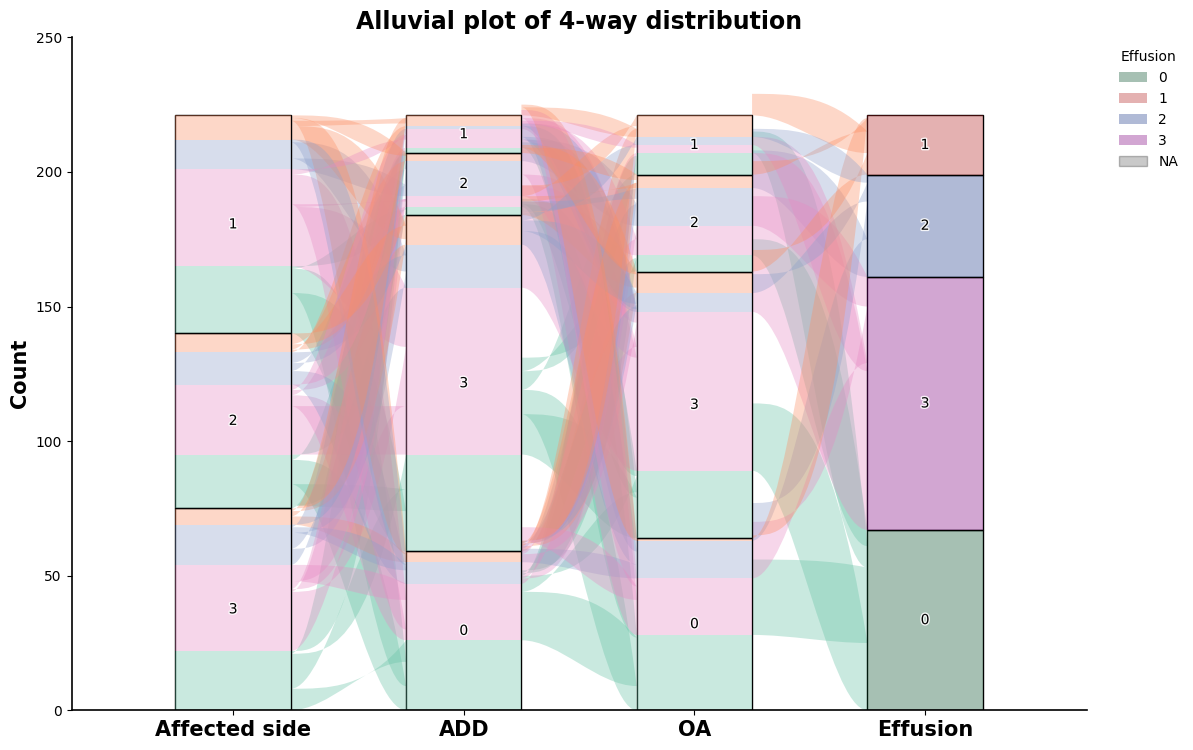

In [2]:
cols = ["Affected side_123", "ADD_123", "OA_123", "Effusion_123"]

effusion_palette = {"0":"#66c2a5","1":"#fc8d62","2":"#8da0cb","3":"#e78ac3","NA":"#ffffff"}
effusion_edge = "#404040"
seg_alpha = 0.35

def darken(hexcolor, factor=0.7):

    if hexcolor.startswith("#") and len(hexcolor) == 7:
        r = int(hexcolor[1:3], 16)
        g = int(hexcolor[3:5], 16)
        b = int(hexcolor[5:7], 16)
        r = int(max(0, min(255, r * factor)))
        g = int(max(0, min(255, g * factor)))
        b = int(max(0, min(255, b * factor)))
        return "#{:02x}{:02x}{:02x}".format(r, g, b)
    return hexcolor

effusion_palette_dark = {
    "0": "#004d26",
    "1": "#b22222",
    "2": "#1e3a8a",
    "3": "#800080",
    "NA": "#666666"
}

# ---- Data Preprocessing ----
df_alluv = df.copy()
for c in cols:
    df_alluv[c] = df_alluv[c].where(df_alluv[c].notna(), "NA").astype(str)


order_map = {
    "Affected side_123": ["3","2","1","0","NA"],  # 아래→위: 3,2,1
    "ADD_123":           ["0","3","2","1","NA"],  # 아래→위: 0,3,2,1
    "OA_123":            ["0","3","2","1","NA"],
    "Effusion_123":      ["0","3","2","1","NA"]
}
eff_order = ["0","3","2","1","NA"]

def ordered_levels(c, counts_dict):
    base = order_map.get(c, ["0","1","2","3","NA"])
    ordered = [lv for lv in base if lv in counts_dict]
    rest = [lv for lv in counts_dict if lv not in base]
    return ordered + sorted(rest)


col_counts = {c: df_alluv[c].value_counts(dropna=False).to_dict() for c in cols}
max_total = max(sum(col_counts[c].values()) for c in cols)
block_ranges = {}
for c in cols:
    y = 0
    for lv in ordered_levels(c, col_counts[c]):
        h = col_counts[c][lv]
        block_ranges[(c, lv)] = (y, y + h)
        y += h


segment_heights, segment_start = {}, {}
for c in cols:
    for lv in ordered_levels(c, col_counts[c]):
        sub = df_alluv[df_alluv[c]==lv][cols[-1]].value_counts(dropna=False).to_dict()
        sh = {ec: int(sub.get(ec, 0)) for ec in eff_order}
        segment_heights[(c, lv)] = sh
        y0, _ = block_ranges[(c, lv)]
        ycur, off = y0, {}
        for ec in eff_order:
            off[ec] = ycur
            ycur += sh[ec]
        segment_start[(c, lv)] = off

used_offsets = {(c, lv, ec): 0 for c in cols for lv in col_counts[c] for ec in eff_order}


flows = {}
for s in range(len(cols)-1):
    left, right = cols[s], cols[s+1]
    keys = [left, right] + ([] if right==cols[-1] else [cols[-1]])
    keys = list(dict.fromkeys(keys))
    tmp = df_alluv.groupby(keys, dropna=False, sort=False).size().reset_index(name="count")
    flows[(left, right)] = tmp

def ribbon(ax, x0, x1, y0a, y0b, y1a, y1b, color, alpha):
    verts = [(x0,y0a),(x0+0.33*(x1-x0),y0a),(x0+0.66*(x1-x0),y1a),(x1,y1a),
             (x1,y1b),(x0+0.66*(x1-x0),y0b),(x0+0.33*(x1-x0),y0b),(x0,y0b),(x0,y0a)]
    codes = [Path.MOVETO,Path.CURVE4,Path.CURVE4,Path.CURVE4,
             Path.LINETO,Path.CURVE4,Path.CURVE4,Path.CURVE4,Path.CLOSEPOLY]
    ax.add_patch(PathPatch(Path(verts,codes), facecolor=color, edgecolor="none", alpha=alpha, zorder=1))


fig, ax = plt.subplots(figsize=(12, 7.6))
x_positions = np.arange(len(cols))

for i, c in enumerate(cols):

    bar_palette = effusion_palette_dark if c == "Effusion_123" else effusion_palette
    for lv in ordered_levels(c, col_counts[c]):
        y0, y1 = block_ranges[(c, lv)]

        ax.add_patch(Rectangle((i-0.25, y0), 0.5, (y1-y0),
                               facecolor='none', edgecolor="black", linewidth=1, zorder=2))

        for ec in eff_order:
            h = segment_heights[(c, lv)][ec]
            if h <= 0:
                continue
            ax.add_patch(Rectangle((i-0.25, segment_start[(c, lv)][ec]), 0.5, h,
                                   facecolor=bar_palette.get(ec, "#cccccc"),
                                   edgecolor="none", alpha=seg_alpha, zorder=2))

        if (y1-y0) >= 12:
            ax.text(i, (y0+y1)/2, lv, ha="center", va="center", fontsize=10,
                    color="black",
                    path_effects=[pe.withStroke(linewidth=2, foreground="white", alpha=0.85)],
                    zorder=3)


for s in range(len(cols)-1):
    left, right = cols[s], cols[s+1]
    x0, x1 = x_positions[s] + 0.25, x_positions[s+1] - 0.25
    tmp = flows[(left, right)]
    for _, row in tmp.iterrows():
        lv_l, lv_r = str(row[left]), str(row[right])
        eff_cat = str(row[cols[-1]] if cols[-1] in row.index else row[right])
        cnt = int(row["count"])
        y0a = segment_start[(left, lv_l)][eff_cat]  + used_offsets[(left, lv_l, eff_cat)]
        y0b = y0a + cnt
        y1a = segment_start[(right, lv_r)][eff_cat] + used_offsets[(right, lv_r, eff_cat)]
        y1b = y1a + cnt
        ribbon(ax, x0, x1, y0a, y0b, y1a, y1b,
               color=effusion_palette.get(eff_cat, "#cccccc"), alpha=seg_alpha)
        used_offsets[(left, lv_l, eff_cat)]  += cnt
        used_offsets[(right, lv_r, eff_cat)] += cnt


y_step = 50
ymax = max(200, y_step * ceil(max_total / y_step))
ax.set_ylim(0, ymax); ax.set_xlim(-0.7, len(cols)-0.3)
ax.set_axisbelow(True)
ax.set_yticks(np.arange(0, ymax+1, y_step))
ax.grid(which="major", axis="y", linestyle="-", linewidth=0.8, color="white")
for x in x_positions:
    ax.axvline(x=x, ymin=0, ymax=1, color="white", linewidth=0.8, zorder=0)
for spine in ["left","bottom"]:
    ax.spines[spine].set_visible(True); ax.spines[spine].set_linewidth(1.2); ax.spines[spine].set_color("black")
for spine in ["top","right"]:
    ax.spines[spine].set_visible(False)

ax.set_xticks(x_positions)
ax.set_xticklabels([c.replace("_123", "") for c in cols],
                   fontsize=15, fontweight="bold", color="black")
ax.set_ylabel("Count", fontsize=15, fontweight="bold", color="black")
ax.set_title("Alluvial plot of 4-way distribution",
             fontsize=17, fontweight="bold", color="black")

#ax.set_xticks(x_positions); ax.set_xticklabels(cols, fontsize=15, fontweight="bold", color="black")
#ax.set_ylabel("Count", fontsize=15, fontweight="bold", color="black")
#ax.set_title("Alluvial plot of 4-way distribution", fontsize=17, fontweight="bold", color="black")

legend_keys = ["0","1","2","3","NA"]
legend_handles = [Rectangle((0,0),1,1,
                            facecolor=(effusion_palette_dark[k] if c=="Effusion_123" else effusion_palette[k]),
                            edgecolor=effusion_edge if k=="NA" else "none",
                            alpha=seg_alpha) for k in legend_keys]
ax.legend(legend_handles, legend_keys, title="Effusion",
          loc="upper left", bbox_to_anchor=(1.02, 1.0), frameon=False)
fig.subplots_adjust(right=0.82)

plt.tight_layout()
plt.show()


Correlation Matrix

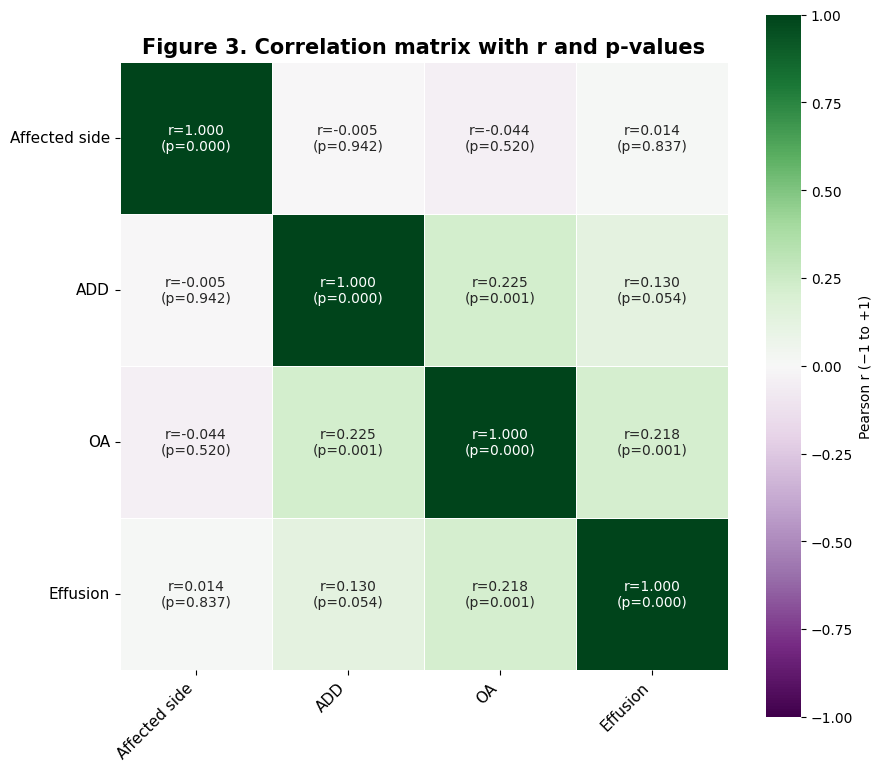

In [3]:
df_encoded = df_alluv.copy()
for c in cols:
    le = LabelEncoder()
    df_encoded[c] = le.fit_transform(df_encoded[c].astype(str))


corr = df_encoded[cols].corr(method="pearson").clip(-1, 1)

pvals = pd.DataFrame(np.ones_like(corr), columns=corr.columns, index=corr.index)
for i in corr.columns:
    for j in corr.columns:
        if i == j:
            pvals.loc[i, j] = 0.0
        else:
            r, p = pearsonr(df_encoded[i], df_encoded[j])
            pvals.loc[i, j] = p


def clean_name(x):
    return re.sub(r'_\d+$', '', x)

corr.index   = [clean_name(x) for x in corr.index]
corr.columns = [clean_name(x) for x in corr.columns]
pvals.index  = corr.index
pvals.columns= corr.columns

annot = corr.copy().astype(str)
for i in corr.index:
    for j in corr.columns:
        annot.loc[i, j] = f"r={corr.loc[i,j]:.3f}\n(p={pvals.loc[i,j]:.3f})"


cmap = sns.color_palette("PRGn", as_cmap=True)
norm = TwoSlopeNorm(vmin=-1, vcenter=0, vmax=1)


plt.figure(figsize=(9,8))
ax = sns.heatmap(
    corr,
    annot=annot, fmt="",
    cmap=cmap, norm=norm,
    vmin=-1, vmax=1,
    linewidths=0.6, linecolor="white",
    square=True, cbar=True,
    cbar_kws={"label":"Pearson r (−1 to +1)"}
)


ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right", fontsize=11)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=11)
plt.title("Figure 3. Correlation matrix with r and p-values", fontsize=15, fontweight="bold")
plt.tight_layout()
plt.show()


Effusion Outcomes

[Info] features = ['Age', 'Sex (Female)', 'VAS', 'CMI', 'Symptom duration', 'TMJ noise', 'Locking', 'Muscle stiffness', 'Tinnitus', 'Bruxism']
[Info] cont_cols = ['Age', 'VAS', 'CMI', 'Symptom duration']

[Effusion 0/1] Logistic Regression
        Variable  B_value    OR  CI_lower  CI_upper  p_value
             Age   -0.081 0.923     0.652     1.306    0.650
    Sex (Female)    0.935 2.547     1.192     5.443    0.016
             VAS    0.786 2.195     1.478     3.258    0.000
             CMI    0.435 1.545     1.062     2.249    0.023
Symptom duration    0.731 2.078     1.044     4.135    0.037
       TMJ noise    1.011 2.749     1.324     5.707    0.007
         Locking    1.104 3.017     1.396     6.523    0.005
Muscle stiffness    0.581 1.788     0.862     3.712    0.119
        Tinnitus    1.298 3.663     1.574     8.520    0.003
         Bruxism   -0.454 0.635     0.273     1.480    0.293
[forest_plot] significant = 7/10


/tmp/ipykernel_1283/2838075756.py:140: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[ 5.56470102e-01 -1.17328338e+00 -1.11748488e+00  7.79664100e-01
  4.44873103e-01  2.06302958e+00 -5.59499885e-01  1.33764909e+00
  7.23865600e-01 -3.36305888e-01 -8.38492382e-01  1.89563409e+00
 -1.00588788e+00 -1.17328338e+00  2.00723109e+00  1.61664159e+00
  1.00285810e+00  7.23865600e-01  1.65880607e-01 -1.51489139e-03
 -3.36305888e-01 -5.03701386e-01  2.56521608e+00 -1.22908188e+00
 -8.94290881e-01  2.77477605e-01 -3.36305888e-01 -2.24708889e-01
 -8.38492382e-01 -8.94290881e-01 -1.51489139e-03  5.00671603e-01
  5.00671603e-01  1.17025360e+00  7.79664100e-01 -8.94290881e-01
  1.50504459e+00  4.44873103e-01  1.10082107e-01 -1.00588788e+00
  1.65880607e-01 -5.73133907e-02 -1.17328338e+00 -1.11748488e+00
  1.95143259e+00  1.39344759e+00 -1.00588788e+00 -1.00588788e+00
 -1.28488038e+00 -1.39647738e+00 -1.51489139e-03 -6.15298384e-0

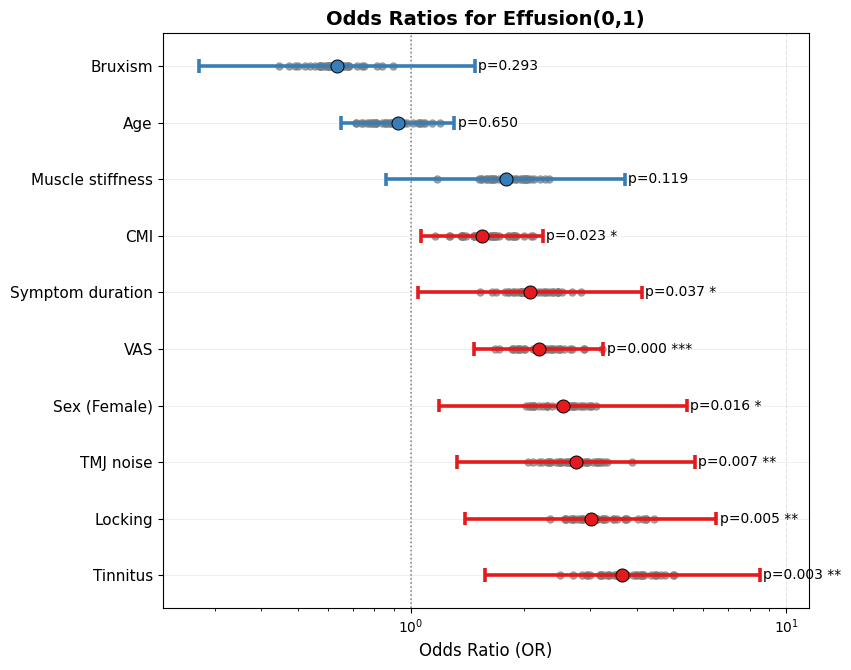

/tmp/ipykernel_1283/2838075756.py:186: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[ 5.56470102e-01 -1.17328338e+00 -1.11748488e+00  7.79664100e-01
  4.44873103e-01  2.06302958e+00 -5.59499885e-01  1.33764909e+00
  7.23865600e-01 -3.36305888e-01 -8.38492382e-01  1.89563409e+00
 -1.00588788e+00 -1.17328338e+00  2.00723109e+00  1.61664159e+00
  1.00285810e+00  7.23865600e-01  1.65880607e-01 -1.51489139e-03
 -3.36305888e-01 -5.03701386e-01  2.56521608e+00 -1.22908188e+00
 -8.94290881e-01  2.77477605e-01 -3.36305888e-01 -2.24708889e-01
 -8.38492382e-01 -8.94290881e-01 -1.51489139e-03  5.00671603e-01
  5.00671603e-01  1.17025360e+00  7.79664100e-01 -8.94290881e-01
  1.50504459e+00  4.44873103e-01  1.10082107e-01 -1.00588788e+00
  1.65880607e-01 -5.73133907e-02 -1.17328338e+00 -1.11748488e+00
  1.95143259e+00  1.39344759e+00 -1.00588788e+00 -1.00588788e+00
 -1.28488038e+00 -1.39647738e+00 -1.51489139e-03 -6.15298384e-0

[Info] OrderedLogit n = 221
[Info] Effusion grade counts:
 Effusion grade
0    67
1    90
2    64
Name: count, dtype: int64

[Effusion grade 0/1/2] Ordered Logistic Regression
        Variable  B_value  OR_per_grade↑  CI_lower  CI_upper  p_value
             Age   -0.067          0.935     0.718     1.218    0.619
    Sex (Female)    1.022          2.778     1.553     4.969    0.001
             VAS    0.707          2.028     1.513     2.719    0.000
             CMI    0.521          1.684     1.259     2.253    0.000
Symptom duration    0.045          1.046     0.815     1.341    0.725
       TMJ noise    0.718          2.050     1.171     3.589    0.012
         Locking    0.895          2.448     1.393     4.301    0.002
Muscle stiffness    0.426          1.531     0.883     2.653    0.129
        Tinnitus    0.824          2.280     1.295     4.016    0.004
         Bruxism   -0.319          0.727     0.383     1.381    0.330
[forest_plot] significant = 6/10


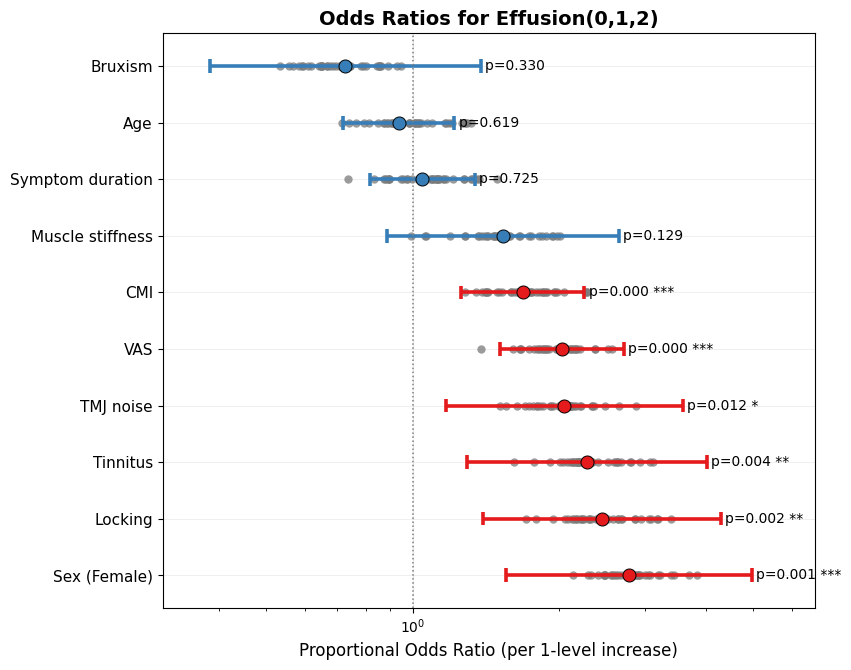

In [4]:
# ================== Effusion Outcomes (0/1, 0/1/2) ==================
# Outcome 1: Effusion (0/1) → Logistic Regression
# Outcome 2: Effusion grade (0/1/2) → Ordered Logistic Regression
# ====================================================================

sex_candidates = ['Sex (Female)', 'Sex (female)', 'Sex(Female)', 'Sex_female', 'Female', 'Sex']
sex_col = next((c for c in sex_candidates if c in df.columns), None)

features = [
    'Age',
    'VAS', 'CMI',
    'Symptom duration',
    'TMJ noise','Locking','Muscle stiffness','Tinnitus','Bruxism'
]

if sex_col is not None:
    features = ['Age', sex_col] + [c for c in features if c != 'Age']
else:
    print("[Warning] Sex (Female) 컬럼 후보를 찾지 못했습니다. 성별 없이 진행합니다.")

features = [c for c in features if c in df.columns]

cont_cols = [c for c in ['Age','VAS','CMI','Symptom duration'] if c in features]

if sex_col is not None and sex_col in df.columns and df[sex_col].dtype == 'O':
    s = df[sex_col].astype(str).str.strip().str.lower()
    sex_map = {
        'female': 1, 'f': 1, 'woman': 1, '여': 1, '여성': 1,
        'male': 0, 'm': 0, 'man': 0, '남': 0, '남성': 0
    }
    if s.isin(sex_map.keys()).any():
        df = df.copy()
        df[sex_col] = s.map(sex_map)

print("[Info] features =", features)
print("[Info] cont_cols =", cont_cols)

def _clean_or_table(table: pd.DataFrame, or_col='OR'):
    t = table.copy()
    if 'Variable' in t.columns:
        t = t[t['Variable']!='const']
    for c in [or_col, 'CI_lower', 'CI_upper'] + (['p_value'] if 'p_value' in t.columns else []):
        t[c] = pd.to_numeric(t[c], errors='coerce')

    m = (np.isfinite(t[or_col]) & np.isfinite(t['CI_lower']) &
         np.isfinite(t['CI_upper']) & (t['CI_lower']>0) & (t['CI_upper']>0))
    if (~m).any():
        print('[forest_plot] Dropped (invalid OR/CI):', t.loc[~m,'Variable'].tolist())

    t = t.loc[m].copy()
    eps = 1e-6
    t['CI_lower'] = t['CI_lower'].clip(lower=eps)
    t[or_col]     = t[or_col].clip(lower=eps)
    return t

# -----------------------
# Forest plot
# -----------------------
def forest_plot(table, title, or_col='OR', xlab='Odds Ratio (OR)', raw_data_X=None):
    """
    - 유의(p<0.05 or CI excludes 1): 빨강
    - 비유의: 파랑
    - raw dot: 항상 회색
    """
    t = _clean_or_table(table, or_col=or_col).copy()

    if 'p_value' in t.columns:
        t['p_value'] = pd.to_numeric(t['p_value'], errors='coerce')

    sig_by_p  = (t['p_value'] < 0.05) if 'p_value' in t.columns else False
    sig_by_ci = (t['CI_lower'] > 1.0) | (t['CI_upper'] < 1.0)
    t['is_significant'] = sig_by_p | sig_by_ci

    print(f"[forest_plot] significant = {int(t['is_significant'].sum())}/{len(t)}")

    t = t.sort_values(['is_significant', or_col], ascending=[False, False]).reset_index(drop=True)

    fig, ax = plt.subplots(figsize=(8.6, 0.5*len(t)+1.8))

    for i, row in t.iterrows():
        color = "#E41A1C" if row['is_significant'] else "#377EB8"  # 빨강/파랑

        # (1) distribution dot
        if raw_data_X is not None and row['Variable'] in raw_data_X.columns:
            if 'B_value' in row.index:
                b = row['B_value']
                scatter_x = np.exp(b + np.random.normal(0, 0.15, 36))
                ax.scatter(scatter_x, np.full_like(scatter_x, i),
                           color="#7A7A7A", s=36, alpha=0.75, zorder=1, linewidths=0)

        # (2) CI Line
        ax.hlines(i, row['CI_lower'], row['CI_upper'], color=color, lw=2.6, zorder=2)
        ax.vlines(row['CI_lower'], i-0.12, i+0.12, color=color, lw=2.6, zorder=2)
        ax.vlines(row['CI_upper'], i-0.12, i+0.12, color=color, lw=2.6, zorder=2)

        # (3) OR Dot
        ax.scatter(row[or_col], i, color=color, s=88, zorder=3,
                   edgecolors="black", linewidths=0.7)

        # (4) p-value text
        if 'p_value' in t.columns and pd.notnull(row['p_value']):
            stars = '***' if row['p_value']<0.001 else '**' if row['p_value']<0.01 else '*' if row['p_value']<0.05 else ''
            ax.text(max(row[or_col], row['CI_upper'])*1.02, i,
                    f"p={row['p_value']:.3f} {stars}",
                    va='center', fontsize=10, color='black')

    ax.axvline(1, color='gray', linestyle=':', lw=1.1)
    ax.set_yticks(np.arange(len(t)))
    ax.set_yticklabels(t['Variable'], fontsize=11)
    ax.set_xlabel(xlab, fontsize=12)
    ax.set_title(title, fontsize=14, fontweight='bold')
    ax.set_xscale('log')

    xmin = max(0.01, t['CI_lower'].min()*0.8)
    xmax = t['CI_upper'].max()*1.35
    if t[or_col].min() < 1 and xmin > t[or_col].min()*0.5:
        xmin = t[or_col].min()*0.5
    if xmax < 2.2: xmax = 2.2
    ax.set_xlim(xmin, xmax)

    ax.grid(axis='x', linestyle='--', alpha=0.35)
    for y in range(len(t)):
        ax.hlines(y, xmin, xmax, colors="#EDEDED", linestyles='-', lw=0.6, zorder=0)

    plt.tight_layout()
    plt.show()

# ===========================================================================
# analyze 1) Outcome = Effusion(0/1)
# ===========================================================================
assert 'Effusion' in df.columns
dat1 = df[features + ['Effusion']].dropna().copy()

for c in features + ['Effusion']:
    dat1[c] = pd.to_numeric(dat1[c], errors='coerce')
dat1 = dat1.dropna().copy()

if cont_cols:
    scaler = StandardScaler()
    dat1.loc[:, cont_cols] = scaler.fit_transform(dat1[cont_cols])

Xb = sm.add_constant(dat1[features], has_constant='add')
y1 = dat1['Effusion'].astype(int)

model1 = sm.Logit(y1, Xb)
try:
    res1 = model1.fit(disp=False)
except Exception:
    res1 = model1.fit_regularized(alpha=0.1, L1_wt=0.0, disp=False)

coef1 = res1.params; pv1 = res1.pvalues; ci1 = res1.conf_int()

tbl1 = pd.DataFrame({
    'Variable': coef1.index,
    'B_value': coef1.values,
    'OR': np.exp(coef1.values),
    'CI_lower': np.exp(ci1.iloc[:,0].values),
    'CI_upper': np.exp(ci1.iloc[:,1].values),
    'p_value': pv1.values
}).query("Variable!='const'")

if sex_col is not None:
    tbl1['Variable'] = tbl1['Variable'].replace({sex_col: 'Sex (Female)'})

print("\n[Effusion 0/1] Logistic Regression")
print(tbl1.round(3).to_string(index=False))

forest_plot(
    tbl1,
    "Odds Ratios for Effusion(0,1)",
    raw_data_X=dat1[features].rename(columns={sex_col:'Sex (Female)'} if sex_col else {})
)

# ===========================================================================
# analyze 2) Outcome = Effusion grade(0/1/2)
# ===========================================================================
assert 'Effusion grade' in df.columns
dat2 = df[features + ['Effusion grade']].dropna().copy()

for c in features + ['Effusion grade']:
    dat2[c] = pd.to_numeric(dat2[c], errors='coerce')
dat2 = dat2.dropna().copy()

if cont_cols:
    scaler = StandardScaler()
    dat2.loc[:, cont_cols] = scaler.fit_transform(dat2[cont_cols])

Xo = dat2[features]
y2 = dat2['Effusion grade'].astype(int)

valid2 = y2.isin([0,1,2])
Xo = Xo.loc[valid2]
y2 = y2.loc[valid2]

print(f"[Info] OrderedLogit n = {len(y2)}")
print("[Info] Effusion grade counts:\n", y2.value_counts().sort_index())

model2 = OrderedModel(y2, Xo, distr='logit')
try:
    res2 = model2.fit(method='bfgs', disp=False)
except Exception:

    try:
        res2 = model2.fit_regularized(method='l1', alpha=0.1, disp=False)
    except Exception:
        res2 = model2.fit(method='lbfgs', disp=False)

coef2 = res2.params.filter(items=features)
pv2   = res2.pvalues.filter(items=features)
ci2   = res2.conf_int().filter(items=features, axis=0)

tbl2 = pd.DataFrame({
    'Variable': coef2.index,
    'B_value': coef2.values,
    'OR_per_grade↑': np.exp(coef2.values),
    'CI_lower': np.exp(ci2.iloc[:,0].values),
    'CI_upper': np.exp(ci2.iloc[:,1].values),
    'p_value': pv2.values
})

if sex_col is not None:
    tbl2['Variable'] = tbl2['Variable'].replace({sex_col: 'Sex (Female)'})

print("\n[Effusion grade 0/1/2] Ordered Logistic Regression")
print(tbl2.round(3).to_string(index=False))

forest_plot(
    tbl2.rename(columns={'OR_per_grade↑':'OR'}),
    "Odds Ratios for Effusion(0,1,2)",
    or_col='OR',
    xlab='Proportional Odds Ratio (per 1-level increase)',
    raw_data_X=dat2[features].rename(columns={sex_col:'Sex (Female)'} if sex_col else {})
)

FULL + BACKWARD

[Info] features = ['Age', 'Sex (Female)', 'VAS', 'CMI', 'Symptom duration', 'TMJ noise', 'Locking', 'Muscle stiffness', 'Tinnitus', 'Bruxism']

[High-grade Logistic]
                          Variable        OR  CI_lower  CI_upper   p_value
Age                            Age  0.918153  0.655082  1.286870  0.620077
Sex (Female)          Sex (Female)  3.287496  1.465117  7.376636  0.003899
VAS                            VAS  2.106693  1.461141  3.037458  0.000066
CMI                            CMI  1.711775  1.241646  2.359911  0.001034
Symptom duration  Symptom duration  0.725756  0.468694  1.123808  0.150782
TMJ noise                TMJ noise  1.567630  0.773213  3.178248  0.212504
Locking                    Locking  2.013918  1.000945  4.052038  0.049691
Muscle stiffness  Muscle stiffness  1.374324  0.686895  2.749717  0.368879
Tinnitus                  Tinnitus  1.446193  0.717659  2.914303  0.302085
Bruxism                    Bruxism  0.723524  0.310841  1.684099  0.452794


/tmp/ipykernel_1283/3813140515.py:78: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[ 5.56470102e-01 -1.17328338e+00 -1.11748488e+00  7.79664100e-01
  4.44873103e-01  2.06302958e+00 -5.59499885e-01  1.33764909e+00
  7.23865600e-01 -3.36305888e-01 -8.38492382e-01  1.89563409e+00
 -1.00588788e+00 -1.17328338e+00  2.00723109e+00  1.61664159e+00
  1.00285810e+00  7.23865600e-01  1.65880607e-01 -1.51489139e-03
 -3.36305888e-01 -5.03701386e-01  2.56521608e+00 -1.22908188e+00
 -8.94290881e-01  2.77477605e-01 -3.36305888e-01 -2.24708889e-01
 -8.38492382e-01 -8.94290881e-01 -1.51489139e-03  5.00671603e-01
  5.00671603e-01  1.17025360e+00  7.79664100e-01 -8.94290881e-01
  1.50504459e+00  4.44873103e-01  1.10082107e-01 -1.00588788e+00
  1.65880607e-01 -5.73133907e-02 -1.17328338e+00 -1.11748488e+00
  1.95143259e+00  1.39344759e+00 -1.00588788e+00 -1.00588788e+00
 -1.28488038e+00 -1.39647738e+00 -1.51489139e-03 -6.15298384e-01

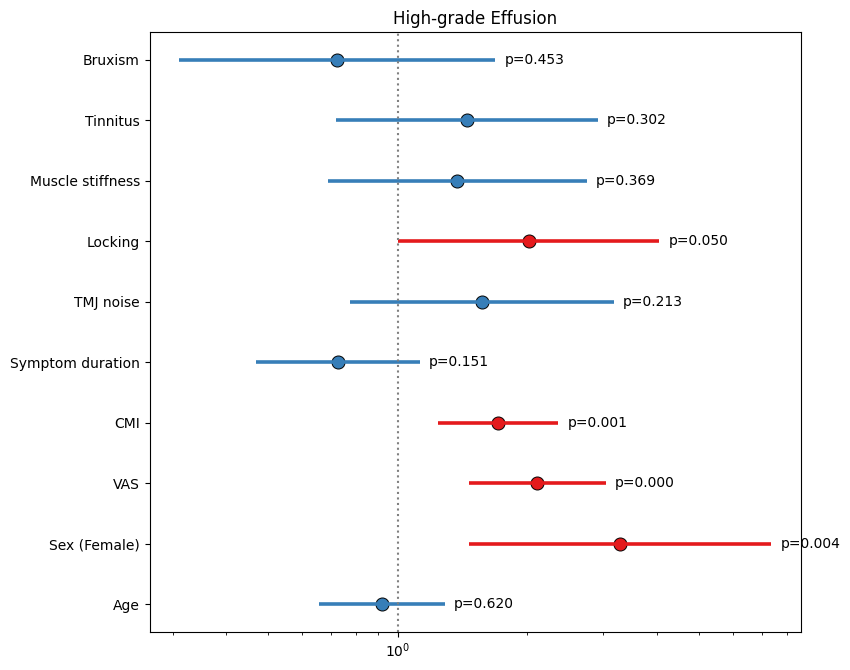

/tmp/ipykernel_1283/3813140515.py:110: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[ 5.56470102e-01 -1.17328338e+00 -1.11748488e+00  7.79664100e-01
  4.44873103e-01  2.06302958e+00 -5.59499885e-01  1.33764909e+00
  7.23865600e-01 -3.36305888e-01 -8.38492382e-01  1.89563409e+00
 -1.00588788e+00 -1.17328338e+00  2.00723109e+00  1.61664159e+00
  1.00285810e+00  7.23865600e-01  1.65880607e-01 -1.51489139e-03
 -3.36305888e-01 -5.03701386e-01  2.56521608e+00 -1.22908188e+00
 -8.94290881e-01  2.77477605e-01 -3.36305888e-01 -2.24708889e-01
 -8.38492382e-01 -8.94290881e-01 -1.51489139e-03  5.00671603e-01
  5.00671603e-01  1.17025360e+00  7.79664100e-01 -8.94290881e-01
  1.50504459e+00  4.44873103e-01  1.10082107e-01 -1.00588788e+00
  1.65880607e-01 -5.73133907e-02 -1.17328338e+00 -1.11748488e+00
  1.95143259e+00  1.39344759e+00 -1.00588788e+00 -1.00588788e+00
 -1.28488038e+00 -1.39647738e+00 -1.51489139e-03 -6.15298384e-0


[Ordered Logistic - FULL]
                          Variable        OR  CI_lower  CI_upper   p_value
Age                            Age  0.935254  0.718109  1.218061  0.619487
Sex (Female)          Sex (Female)  2.778386  1.553389  4.969414  0.000572
VAS                            VAS  2.028449  1.513210  2.719125  0.000002
CMI                            CMI  1.684018  1.258871  2.252747  0.000447
Symptom duration  Symptom duration  1.045638  0.815419  1.340854  0.725045
TMJ noise                TMJ noise  2.049841  1.170895  3.588577  0.012000
Locking                    Locking  2.447615  1.392759  4.301405  0.001861
Muscle stiffness  Muscle stiffness  1.530796  0.883354  2.652773  0.129058
Tinnitus                  Tinnitus  2.280153  1.294718  4.015623  0.004311
Bruxism                    Bruxism  0.726987  0.382811  1.380605  0.329875


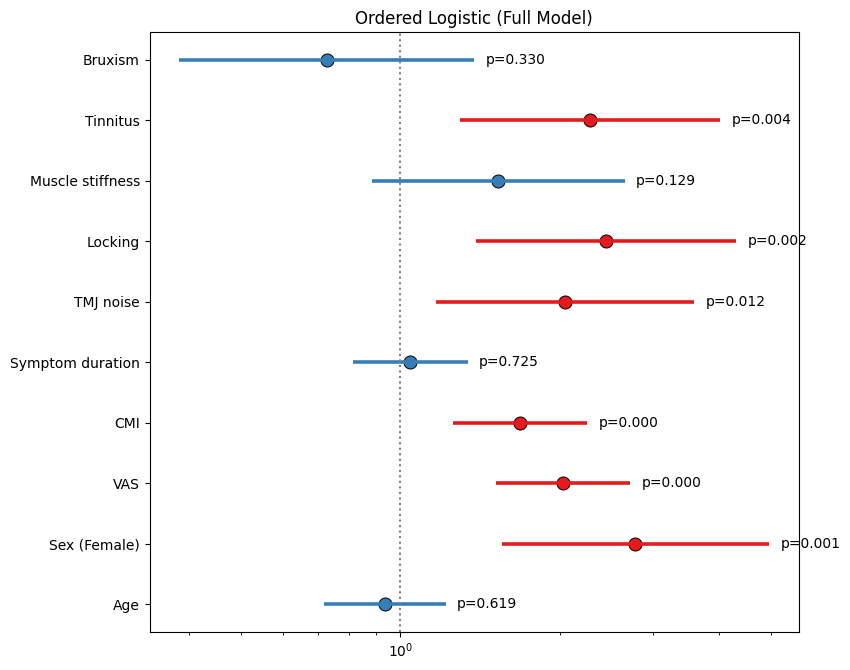

[Backward] remove Symptom duration (p=0.725)
[Backward] remove Age (p=0.600)
[Backward] remove Bruxism (p=0.361)
[Backward] remove Muscle stiffness (p=0.168)

[Ordered Logistic - BACKWARD]
                  Variable        OR  CI_lower  CI_upper       p_value
Sex (Female)  Sex (Female)  2.750938  1.548914  4.885785  5.543600e-04
VAS                    VAS  2.083099  1.564904  2.772885  4.941416e-07
CMI                    CMI  1.684021  1.260001  2.250732  4.290235e-04
TMJ noise        TMJ noise  1.943519  1.119403  3.374356  1.824159e-02
Locking            Locking  2.609381  1.507424  4.516891  6.127702e-04
Tinnitus          Tinnitus  2.262902  1.288823  3.973179  4.463550e-03


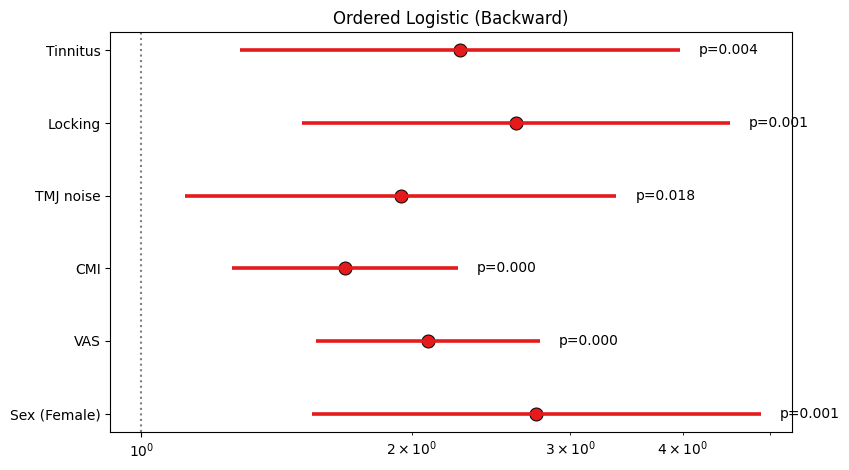

In [5]:
# -----------------------
# 0) Predictor setup
# -----------------------
sex_candidates = ['Sex (Female)', 'Sex (female)', 'Sex(Female)', 'Sex_female', 'Female', 'Sex']
sex_col = next((c for c in sex_candidates if c in df.columns), None)

features = [
    'Age',
    'VAS', 'CMI',
    'Symptom duration',
    'TMJ noise','Locking','Muscle stiffness','Tinnitus','Bruxism'
]

if sex_col is not None:
    features = ['Age', sex_col] + [c for c in features if c != 'Age']

features = [c for c in features if c in df.columns]
cont_cols = [c for c in ['Age','VAS','CMI','Symptom duration'] if c in features]

print("[Info] features =", features)

# -----------------------
#  forest plot
# -----------------------
def _clean_or_table(table: pd.DataFrame, or_col='OR'):
    t = table.copy()
    if 'Variable' in t.columns:
        t = t[t['Variable']!='const']
    for c in [or_col, 'CI_lower', 'CI_upper'] + (['p_value'] if 'p_value' in t.columns else []):
        t[c] = pd.to_numeric(t[c], errors='coerce')

    m = (np.isfinite(t[or_col]) & np.isfinite(t['CI_lower']) &
         np.isfinite(t['CI_upper']) & (t['CI_lower']>0) & (t['CI_upper']>0))
    t = t.loc[m].copy()

    return t

def forest_plot(table, title, or_col='OR', xlab='Odds Ratio (OR)'):
    t = _clean_or_table(table, or_col=or_col).copy()

    t['is_significant'] = (t['p_value'] < 0.05)

    fig, ax = plt.subplots(figsize=(8.6, 0.5*len(t)+1.8))

    for i, row in t.iterrows():
        color = "#E41A1C" if row['is_significant'] else "#377EB8"

        ax.hlines(i, row['CI_lower'], row['CI_upper'], color=color, lw=2.6)
        ax.scatter(row[or_col], i, color=color, s=88,
                   edgecolors="black", linewidths=0.7)

        ax.text(max(row[or_col], row['CI_upper'])*1.05, i,
                f"p={row['p_value']:.3f}",
                va='center', fontsize=10)

    ax.axvline(1, color='gray', linestyle=':')
    ax.set_yticks(np.arange(len(t)))
    ax.set_yticklabels(t['Variable'])
    ax.set_xscale('log')
    ax.set_title(title)

    plt.tight_layout()
    plt.show()

# ======================================================================
# 1) High grade logistic (0/1 vs 2)
# ======================================================================
dat = df[features + ['Effusion grade']].dropna().copy()

for c in dat.columns:
    dat[c] = pd.to_numeric(dat[c], errors='coerce')

dat = dat[dat['Effusion grade'].isin([0,1,2])]
dat['Effusion_high'] = (dat['Effusion grade']==2).astype(int)

if cont_cols:
    scaler = StandardScaler()
    dat.loc[:, cont_cols] = scaler.fit_transform(dat[cont_cols])

X = sm.add_constant(dat[features])
y = dat['Effusion_high']

res = sm.Logit(y, X).fit(disp=False)

tbl_high = pd.DataFrame({
    'Variable': res.params.index,
    'OR': np.exp(res.params),
    'CI_lower': np.exp(res.conf_int()[0]),
    'CI_upper': np.exp(res.conf_int()[1]),
    'p_value': res.pvalues
}).query("Variable!='const'")

print("\n[High-grade Logistic]")
print(tbl_high)

forest_plot(tbl_high, "High-grade Effusion")

# ======================================================================
# 2) Ordered Logistic (FULL MODEL)
# ======================================================================
dat2 = df[features + ['Effusion grade']].dropna().copy()

for c in dat2.columns:
    dat2[c] = pd.to_numeric(dat2[c], errors='coerce')

dat2 = dat2[dat2['Effusion grade'].isin([0,1,2])]

if cont_cols:
    scaler = StandardScaler()
    dat2.loc[:, cont_cols] = scaler.fit_transform(dat2[cont_cols])

Xo = dat2[features]
y2 = dat2['Effusion grade']

model_full = OrderedModel(y2, Xo, distr='logit')
res_full = model_full.fit(method='bfgs', disp=False)

tbl_full = pd.DataFrame({
    'Variable': features,
    'OR': np.exp(res_full.params[features]),
    'CI_lower': np.exp(res_full.conf_int().loc[features][0]),
    'CI_upper': np.exp(res_full.conf_int().loc[features][1]),
    'p_value': res_full.pvalues[features]
})

print("\n[Ordered Logistic - FULL]")
print(tbl_full)

forest_plot(tbl_full, "Ordered Logistic (Full Model)",
            xlab='Proportional Odds Ratio')

# ======================================================================
# 3) Ordered Logistic (BACKWARD)
# ======================================================================
def backward_selection(X, y, features, threshold=0.05):
    selected = features.copy()

    while True:
        model = OrderedModel(y, X[selected], distr='logit')
        res = model.fit(method='bfgs', disp=False)

        pvals = res.pvalues[selected]
        max_p = pvals.max()

        if max_p > threshold:
            remove_var = pvals.idxmax()
            print(f"[Backward] remove {remove_var} (p={max_p:.3f})")
            selected.remove(remove_var)
        else:
            break

    return selected, res

selected, res_back = backward_selection(Xo, y2, features)

tbl_back = pd.DataFrame({
    'Variable': selected,
    'OR': np.exp(res_back.params[selected]),
    'CI_lower': np.exp(res_back.conf_int().loc[selected][0]),
    'CI_upper': np.exp(res_back.conf_int().loc[selected][1]),
    'p_value': res_back.pvalues[selected]
})

print("\n[Ordered Logistic - BACKWARD]")
print(tbl_back)

forest_plot(tbl_back, "Ordered Logistic (Backward)",
            xlab='Proportional Odds Ratio')

Violin + scatter

/tmp/ipykernel_277/2894090681.py:121: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
/tmp/ipykernel_277/2894090681.py:121: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
/tmp/ipykernel_277/2894090681.py:121: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
/tmp/ipykernel_277/2894090681.py:121: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


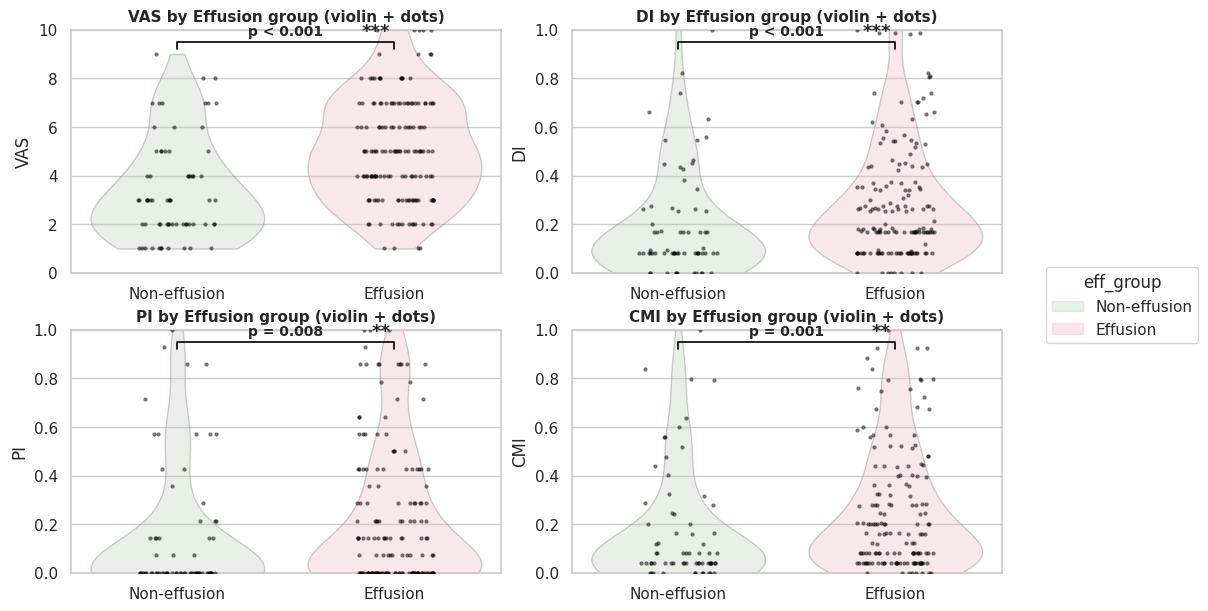

In [ ]:
# ============================================================
# Violin + scatter (transparent) for VAS, DI, PI, CMI by eff_group
# - Values clipped to max: VAS=10, DI/PI/CMI=1 (exceed -> max)
# - Smaller figure size
# - Legend shown with title: eff_group
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import mannwhitneyu
import matplotlib.patches as mpatches

# ---------------------------
# 0) Load data
# ---------------------------
file_path = '/content/drive/MyDrive/Effusion OSA TMD/20260211_Effusion_TMD_Pain_Data.xlsx'
df = pd.read_excel(file_path, sheet_name='20250830_20250829_20250226_2024')

# ---------------------------
# 1) Build eff_group label (robust)
# ---------------------------
def make_eff_group(series: pd.Series) -> pd.Series:
    s = series.copy()
    if pd.api.types.is_numeric_dtype(s):
        return s.map({0: 'Non-effusion', 1: 'Effusion'}).fillna(s.astype(str))

    s_str = s.astype(str).str.strip().str.lower()
    eff = s_str.isin(['1', 'yes', 'y', 'true', 'effusion', 'e', 'positive', 'pos'])
    noneff = s_str.isin(['0', 'no', 'n', 'false', 'non-effusion', 'noneffusion', 'non effusion', 'ne', 'negative', 'neg'])

    out = pd.Series(index=s.index, dtype=object)
    out[eff] = 'Effusion'
    out[noneff] = 'Non-effusion'

    mask_na = out.isna()
    out[mask_na & s_str.str.contains('non')] = 'Non-effusion'
    out[mask_na & s_str.str.contains('eff')] = 'Effusion'
    return out.fillna(s.astype(str))

df['eff_group'] = make_eff_group(df['Effusion'])
df = df[df['eff_group'].isin(['Non-effusion', 'Effusion'])].copy()

# ---------------------------
# 2) Clip values to max (exceed -> max)
# ---------------------------
max_map = {"VAS": 10, "DI": 1, "PI": 1, "CMI": 1}
for col, mx in max_map.items():
    df[col] = pd.to_numeric(df[col], errors='coerce').clip(lower=0, upper=mx)

# ---------------------------
# 3) Stats helpers
# ---------------------------
def p_to_stars(p):
    if p < 0.001:
        return '***'
    elif p < 0.01:
        return '**'
    elif p < 0.05:
        return '*'
    else:
        return 'ns'

def mannwhitney_p(x0, x1):
    x0 = pd.to_numeric(x0, errors='coerce').dropna()
    x1 = pd.to_numeric(x1, errors='coerce').dropna()
    if len(x0) == 0 or len(x1) == 0:
        return np.nan
    return mannwhitneyu(x0, x1, alternative='two-sided').pvalue

def annotate_group_p(ax, p, y_max, x0=0, x1=1):
    if np.isnan(p):
        return
    stars = p_to_stars(p)

    # bracket position (near top)
    y = y_max * 0.92
    h = y_max * 0.03

    ax.plot([x0, x0, x1, x1], [y, y + h, y + h, y], lw=1.2, c='black')

    # stars at top-right
    ax.text(x1 - 0.02, y + h + y_max * 0.005, stars,
            ha='right', va='bottom', fontsize=13, fontweight='bold')

    # p text near top-center
    p_text = "p < 0.001" if p < 0.001 else f"p = {p:.3f}"
    ax.text((x0 + x1) / 2, y + h + y_max * 0.015, p_text,
            ha='center', va='bottom', fontsize=10, fontweight='bold')

# ---------------------------
# 4) Plot
# ---------------------------
sns.set(style="whitegrid", context="notebook")

order = ["Non-effusion", "Effusion"]
palette = {"Non-effusion": "#b7d7b7", "Effusion": "#f4b6c2"}

plots = [
    ("VAS", 10, "VAS by Effusion group (violin + dots)"),
    ("DI", 1,  "DI by Effusion group (violin + dots)"),
    ("PI", 1,  "PI by Effusion group (violin + dots)"),
    ("CMI", 1, "CMI by Effusion group (violin + dots)"),
]

# smaller overall size
fig, axes = plt.subplots(2, 2, figsize=(10, 6), constrained_layout=True)
axes = axes.ravel()

def set_violin_alpha(ax, alpha=0.35):
    # seaborn violin bodies are PolyCollection in ax.collections
    for coll in ax.collections:
        try:
            coll.set_alpha(alpha)
        except Exception:
            pass

for ax, (col, y_max, title) in zip(axes, plots):
    # violin
    sns.violinplot(
        data=df, x="eff_group", y=col, order=order,
        palette=palette, inner=None, cut=0, linewidth=1.0, ax=ax
    )
    set_violin_alpha(ax, alpha=0.35)  # 투명도

    # dots
    sns.stripplot(
        data=df, x="eff_group", y=col, order=order,
        color="black", size=3.0, jitter=0.18, alpha=0.55, ax=ax
    )

    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.set_xlabel("")
    ax.set_ylabel(col)
    ax.set_ylim(0, y_max)

    # p-value + stars
    g0 = df.loc[df["eff_group"] == "Non-effusion", col]
    g1 = df.loc[df["eff_group"] == "Effusion", col]
    p = mannwhitney_p(g0, g1)
    annotate_group_p(ax, p, y_max)

# ---- Legend: eff_group 표기 (figure-level)
handles = [
    mpatches.Patch(color=palette["Non-effusion"], label="Non-effusion", alpha=0.35),
    mpatches.Patch(color=palette["Effusion"], label="Effusion", alpha=0.35),
]
fig.legend(handles=handles, title="eff_group", loc="center right", bbox_to_anchor=(1.2, 0.5))

plt.show()

# Optional save:
# out_path = "/content/drive/MyDrive/effusion_violin_2x2_small.png"
# fig.savefig(out_path, dpi=300, bbox_inches="tight")
# print("Saved:", out_path)


Spearman, values shown

/tmp/ipykernel_267/68302502.py:15: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = get_cmap(cmap_name)


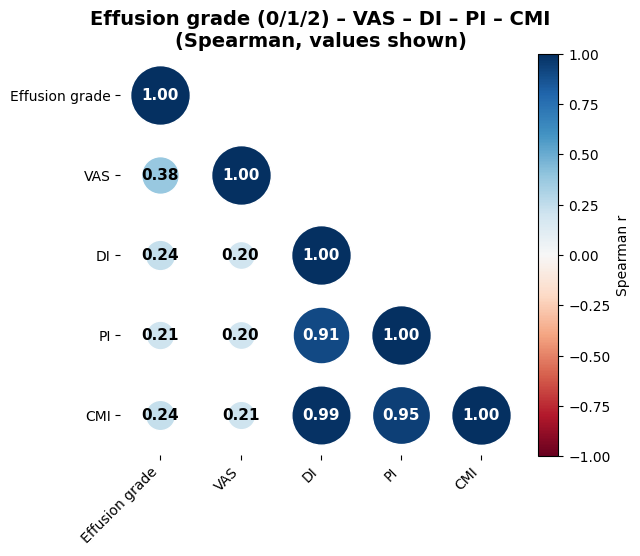

In [ ]:

cols = ['Effusion grade', 'VAS', 'DI', 'PI', 'CMI']
d = df[cols].copy()

for c in cols:
    d[c] = pd.to_numeric(d[c], errors='coerce')

corr = d.corr(method='spearman')

def bubble_corrplot_with_values(corr, figsize=(6.5,6.5), cmap_name='RdBu'):
    labels = corr.columns.tolist()
    n = len(labels)

    fig, ax = plt.subplots(figsize=figsize)

    cmap = get_cmap(cmap_name)
    norm = Normalize(vmin=-1, vmax=1)

    for i in range(n):
        for j in range(n):
            if i >= j:
                r = corr.iloc[i, j]
                if np.isnan(r):
                    continue

                size = abs(r) * 1800 + 50
                color = cmap(norm(r))

                ax.scatter(j, i, s=size, color=color,
                           edgecolor='white', linewidth=1)


                txt_color = 'white' if abs(r) > 0.7 else 'black'
                ax.text(j, i, f"{r:.2f}",
                        ha='center', va='center',
                        fontsize=11, fontweight='bold',
                        color=txt_color)

    ax.set_xticks(range(n))
    ax.set_yticks(range(n))
    ax.set_xticklabels(labels, rotation=45, ha='right')
    ax.set_yticklabels(labels)

    ax.set_xlim(-0.5, n-0.5)
    ax.set_ylim(n-0.5, -0.5)
    ax.set_aspect('equal')
    ax.set_frame_on(False)

    sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])
    cbar = plt.colorbar(sm, ax=ax, fraction=0.046, pad=0.04)
    cbar.set_label('Spearman r')

    plt.title("Effusion grade (0/1/2) – VAS – DI – PI – CMI\n(Spearman, values shown)",
              fontsize=14, fontweight='bold')

    plt.tight_layout()
    plt.show()

bubble_corrplot_with_values(corr)

Pairwise Matrix with Trend Line

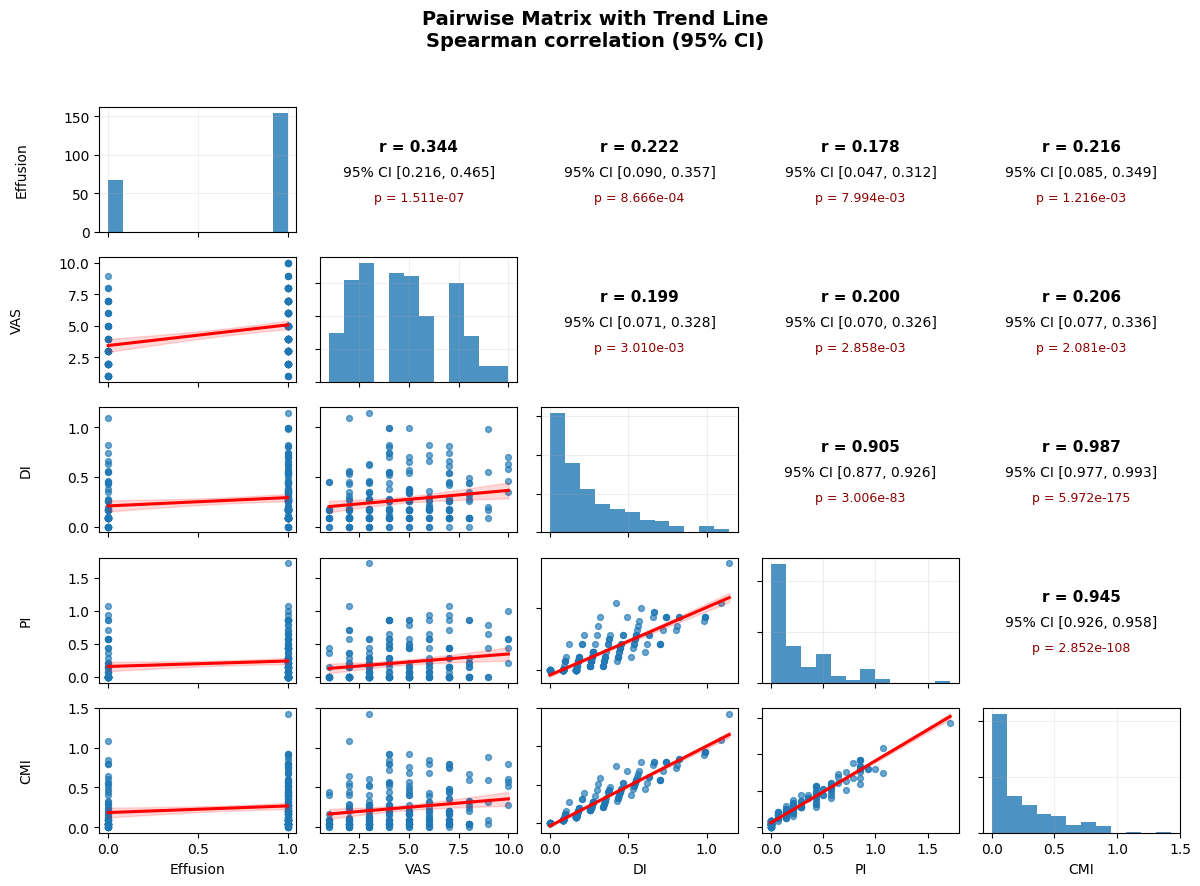

In [ ]:
cols = ['Effusion', 'VAS', 'DI', 'PI', 'CMI']
d = df[cols].copy()

for c in cols:
    d[c] = pd.to_numeric(d[c], errors='coerce')

d = d.dropna().reset_index(drop=True)

def corr_with_ci(x, y, method='spearman', n_boot=2000, seed=42):
    x = np.asarray(x); y = np.asarray(y)
    mask = np.isfinite(x) & np.isfinite(y)
    x = x[mask]; y = y[mask]
    n = len(x)

    if n < 3:
        return np.nan, (np.nan, np.nan), np.nan

    if method == 'pearson':
        r, p = pearsonr(x, y)
    else:
        r, p = spearmanr(x, y)

    rng = np.random.RandomState(seed)
    boots = []
    for _ in range(n_boot):
        idx = rng.randint(0, n, n)
        xb = x[idx]; yb = y[idx]
        if method == 'pearson':
            rb = pearsonr(xb, yb)[0]
        else:
            rb = spearmanr(xb, yb)[0]
        boots.append(rb)

    lo, hi = np.percentile(boots, [2.5, 97.5])
    return r, (lo, hi), p

def add_regression_line(ax, x, y):
    x = np.asarray(x)
    y = np.asarray(y)

    mask = np.isfinite(x) & np.isfinite(y)
    x = x[mask]
    y = y[mask]

    if len(x) < 3:
        return

    # OLS
    X = sm.add_constant(x)
    model = sm.OLS(y, X).fit()

    x_range = np.linspace(x.min(), x.max(), 100)
    X_pred = sm.add_constant(x_range)

    y_pred = model.predict(X_pred)
    pred = model.get_prediction(X_pred)
    ci = pred.conf_int()

    # 🔴 붉은색 추세선 + CI
    ax.plot(x_range, y_pred, color='red', linewidth=2.2)
    ax.fill_between(x_range, ci[:, 0], ci[:, 1],
                    color='red', alpha=0.15)


def scatter_matrix_with_corr(d, method='spearman', n_boot=2000, figsize=(12, 9)):
    cols = d.columns.tolist()
    k = len(cols)

    fig, axes = plt.subplots(k, k, figsize=figsize)

    fig.suptitle(
        f"Pairwise Matrix with Trend Line\n"
        f"{method.capitalize()} correlation (95% CI)",
        fontsize=14, fontweight='bold', y=0.98
    )

    for i in range(k):
        for j in range(k):
            ax = axes[i, j]
            x = d[cols[j]].values
            y = d[cols[i]].values

            if i == j:
                ax.hist(d[cols[i]], bins=12, alpha=0.8)
                ax.grid(alpha=0.2)

            elif i > j:
                # scatter
                ax.scatter(x, y, s=18, alpha=0.65)


                add_regression_line(ax, x, y)

            else:
                # correlation text
                r, (lo, hi), p = corr_with_ci(
                    d[cols[j]], d[cols[i]],
                    method=method, n_boot=n_boot
                )
                ax.axis('off')

                if np.isfinite(r):
                    ax.text(0.5, 0.65, f"r = {r:.3f}",
                            ha='center', fontsize=11, fontweight='bold')
                    ax.text(0.5, 0.45, f"95% CI [{lo:.3f}, {hi:.3f}]",
                            ha='center', fontsize=10)
                    ax.text(0.5, 0.25, f"p = {p:.3e}",
                            ha='center', fontsize=9, color='darkred')


            if i < k - 1:
                ax.set_xticklabels([])
            else:
                ax.set_xlabel(cols[j])

            if j > 0:
                ax.set_yticklabels([])
            else:
                ax.set_ylabel(cols[i], labelpad=25)

    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()


scatter_matrix_with_corr(d, method='spearman', n_boot=2000)